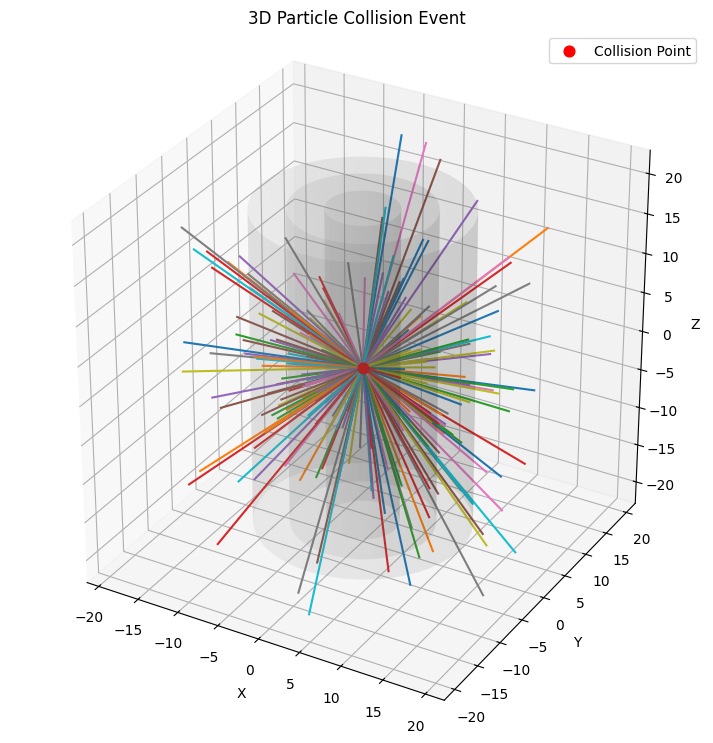

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# number of particles
N = 200

# time steps
t = np.linspace(0,10,100)

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

# detector layers
z_cyl = np.linspace(-20,20,100)
theta_cyl = np.linspace(0,2*np.pi,100)

theta_cyl, z_cyl = np.meshgrid(theta_cyl, z_cyl)

for r in [4,8,12]:
    
    x_cyl = r*np.cos(theta_cyl)
    y_cyl = r*np.sin(theta_cyl)

    ax.plot_surface(x_cyl, y_cyl, z_cyl,
                    alpha=0.1,
                    color='gray',
                    linewidth=0)

for i in range(N):

    theta = np.random.uniform(0,2*np.pi)
    phi = np.random.uniform(0, np.pi)
    speed = np.random.uniform(0.5,2)

    x = speed*t*np.cos(theta)
    y = speed*t*np.sin(theta)
    z = speed * t * np.cos(phi)

    ax.plot(x,y,z)

ax.scatter(0,0,0,color='red',s=60,label="Collision Point")


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Particle Collision Event")
ax.set_box_aspect([1,1,1])
ax.legend()
plt.show()

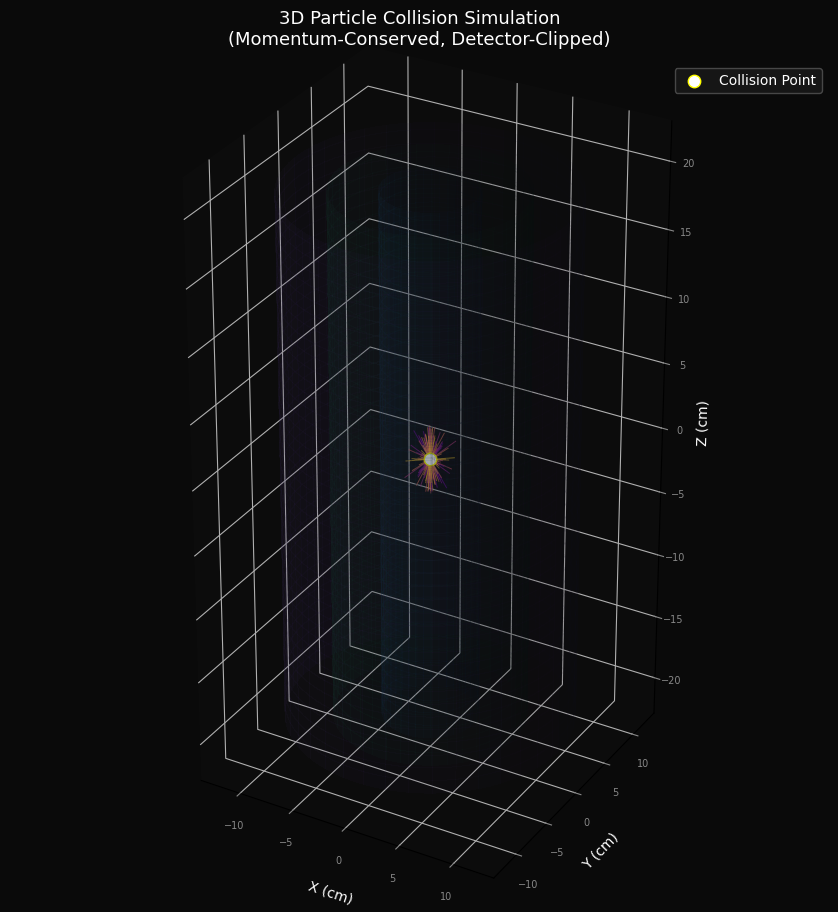

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Configuration ─────────────────────────────────────────────
N       = 200        # total particles (must be even for momentum conservation)
STEPS   = 200        # time steps
R_MAX   = 12         # outermost detector layer radius
Z_MAX   = 20         # detector half-length along z
DT      = 0.08       # time step size

np.random.seed(42)
t = np.linspace(0, 1, STEPS)

# ── Figure setup ──────────────────────────────────────────────
fig = plt.figure(figsize=(9, 9))
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#0a0a0a')
fig.patch.set_facecolor('#0a0a0a')

# ── Detector layers (cylindrical) ─────────────────────────────
z_vals     = np.linspace(-Z_MAX, Z_MAX, 80)
theta_vals = np.linspace(0, 2 * np.pi, 80)
TH, ZZ     = np.meshgrid(theta_vals, z_vals)

layer_colors = ['#1a3a5c', '#1a4a3a', '#3a2a5c']
for r, col in zip([4, 8, 12], layer_colors):
    ax.plot_surface(
        r * np.cos(TH), r * np.sin(TH), ZZ,
        alpha=0.08, color=col, linewidth=0, antialiased=False
    )

# ── Particle generation with momentum conservation ────────────
particle_colors = plt.cm.plasma(np.linspace(0.1, 0.9, N // 2))

for i in range(N // 2):
    theta = np.random.uniform(0, 2 * np.pi)
    phi   = np.random.uniform(0, np.pi)
    speed = np.random.uniform(0.4, 2.5)

    vx =  speed * np.sin(phi) * np.cos(theta)
    vy =  speed * np.sin(phi) * np.sin(theta)
    vz =  speed * np.cos(phi)

    col = particle_colors[i]

    for sign in [1, -1]:
        xs = sign * vx * t
        ys = sign * vy * t
        zs = sign * vz * t

        r_xy   = np.sqrt(xs**2 + ys**2)
        inside = (r_xy <= R_MAX) & (np.abs(zs) <= Z_MAX)
        idx    = np.argmax(~inside)
        if idx == 0 and inside[0]:
            idx = len(t)
        if idx == 0:
            continue

        ax.plot(xs[:idx], ys[:idx], zs[:idx],
                color=col, alpha=0.65, linewidth=0.7)

# ── Collision point ────────────────────────────────────────────
ax.scatter(0, 0, 0, color='white', s=80, zorder=5,
           label='Collision Point', edgecolors='yellow', linewidths=1)

# ── Axes & labels ─────────────────────────────────────────────
for axis, label in zip([ax.xaxis, ax.yaxis, ax.zaxis], ['X (cm)', 'Y (cm)', 'Z (cm)']):
    axis.label.set_color('white')
    axis.set_pane_color((0.05, 0.05, 0.05, 0.8))

ax.tick_params(colors='#888888', labelsize=7)
ax.set_xlabel('X (cm)', labelpad=6)
ax.set_ylabel('Y (cm)', labelpad=6)
ax.set_zlabel('Z (cm)', labelpad=6)
ax.set_title('3D Particle Collision Simulation\n(Momentum-Conserved, Detector-Clipped)',
             color='white', fontsize=13, pad=12)
ax.set_box_aspect([1, 1, 2])

legend = ax.legend(facecolor='#1a1a1a', edgecolor='#555', labelcolor='white')

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

CSV_PATH = "/home/subh25/MuRun2010B.csv"  # ← your actual path

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()  # clean hidden spaces

print("Columns:", df.columns.tolist())
print(df.head(3))

Columns: ['Run', 'Event', 'Type1', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'Type2', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']
      Run     Event Type1       E1       px1      py1       pz1      pt1  \
0  146436  90830792     G  19.1712  3.817130  9.04323 -16.46730  9.81583   
1  146436  90862225     G  12.9435  5.125790 -3.98369 -11.19730  6.49180   
2  146436  90644850     G  12.3999 -0.849742  9.40110   8.04015  9.43943   

      eta1      phi1  ...  Type2        E2       px2      py2       pz2  \
0 -1.28942  1.171390  ...      T   5.43984 -0.362592  2.62699 -4.748490   
1 -1.31335 -0.660674  ...      G  11.86360  4.789840 -6.26222 -8.864340   
2  0.77258  1.660940  ...      G   8.55532 -4.851550  6.97696 -0.983229   

       pt2      eta2      phi2  Q2        M  
0  2.65189 -1.345870  1.707960   1  2.73205  
1  7.88403 -0.966622 -0.917841   1  3.10256  
2  8.49797 -0.115445  2.178410  -1  9.41149  

[3 rows x 21 columns]


✓ Loaded 80 real CMS collision events
  Mass range: 2.00 – 88.84 GeV

⚙  Generating helical tracks (B = 3.8 T)...
✓ 0 tracks drawn,  0 detector hits marked


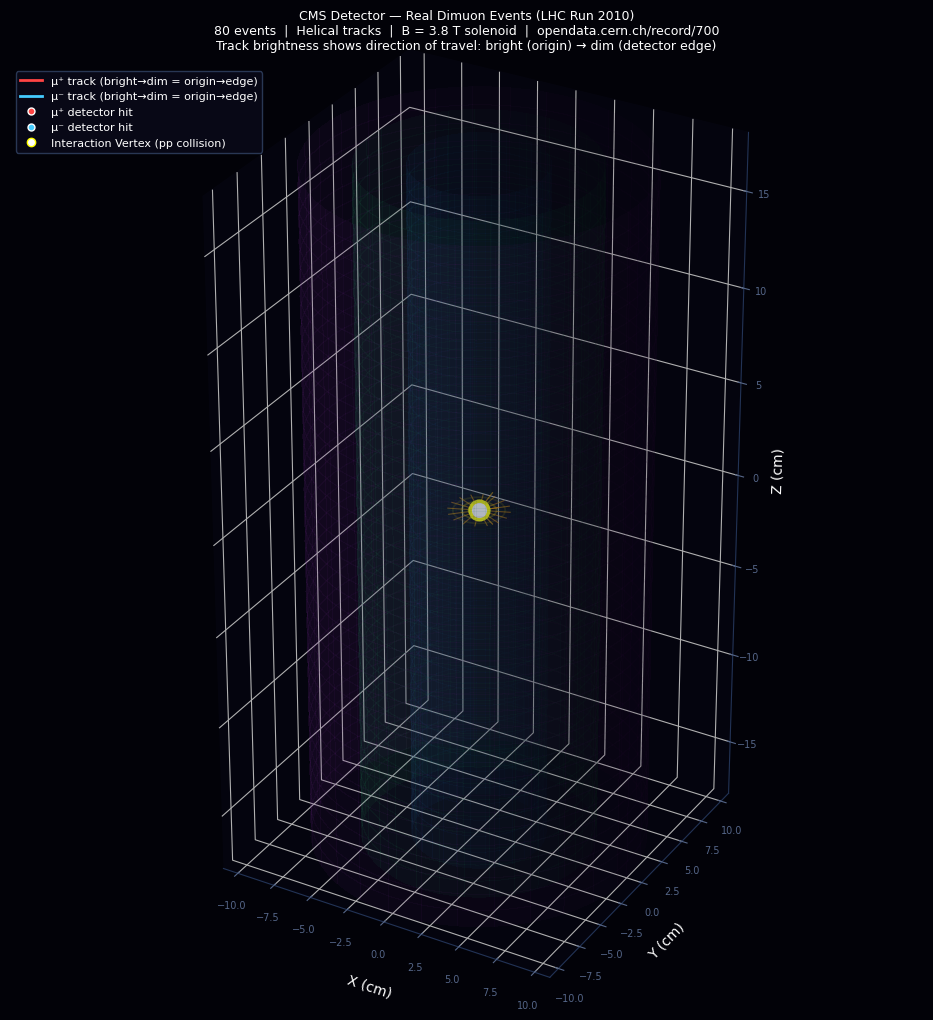


✓ Invariant mass check: max residual = 2.291546 GeV  (should be ~0)


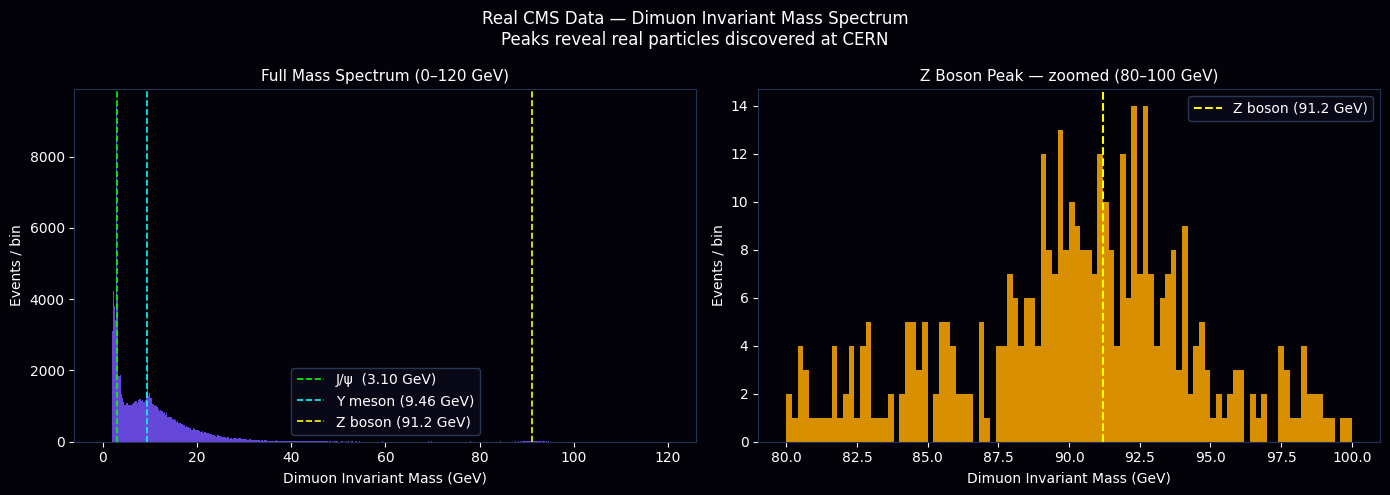

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors


CSV_PATH       = "MuRun2010B.csv"   # ← change to your full desktop path
SAMPLE         = 80                 # number of collision events
B_FIELD        = 3.8                # CMS solenoid magnetic field in Tesla
DETECTOR_RADII = [4, 7, 10]         # detector layer radii in cm
Z_MAX          = 18                 # detector half-length in cm
STEPS          = 200                # points per track (more = smoother)

# Charge color convention (standard HEP)
# Tracks fade from bright (origin) → dim (detector edge)
MUON_COLOR = {1: '#ff4444', -1: '#44ccff'}   # red = μ⁺, cyan = μ⁻

# FUNCTION 1 — LOAD & CLEAN DATA

def load_data(csv_path, sample=80, seed=42):
    """
    Load CMS dimuon CSV, strip whitespace from column names,
    return a reproducible random sample.
    """
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    df = df.sample(n=sample, random_state=seed).reset_index(drop=True)
    print(f"✓ Loaded {len(df)} real CMS collision events")
    print(f"  Mass range: {df['M'].min():.2f} – {df['M'].max():.2f} GeV")
    return df


# FUNCTION 2 — HELIX TRACK GENERATOR

def make_helix(px, py, pz, pt, charge, B=3.8, steps=200, r_max=10, z_max=18):
    """
    Compute helical track coordinates for a charged particle in a solenoid.
    μ⁺ and μ⁻ curve in opposite directions due to opposite sign of q.
    """
    if pt == 0:
        return np.array([]), np.array([]), np.array([])

    r_curve = (pt / (0.3 * B)) * 100
    phi0    = np.arctan2(py, px)
    pitch   = (pz / pt) * r_curve
    x_c     = -charge * r_curve * np.sin(phi0)
    y_c     =  charge * r_curve * np.cos(phi0)

    s  = np.linspace(0, 4 * np.pi, steps)
    xs = x_c + r_curve * np.cos(phi0 - charge * s)
    ys = y_c + r_curve * np.sin(phi0 - charge * s)
    zs = pitch * s

    r_xy   = np.sqrt(xs**2 + ys**2)
    inside = (r_xy <= r_max) & (np.abs(zs) <= z_max)
    idx    = np.argmax(~inside)
    if idx == 0 and inside[0]:
        idx = len(s)
    if idx == 0:
        return np.array([]), np.array([]), np.array([])

    return xs[:idx], ys[:idx], zs[:idx]



# FUNCTION 3 — FIND HIT POSITIONS ON DETECTOR LAYERS

def find_hits(xs, ys, zs, detector_radii):
    """
    Find where a helical track crosses each cylindrical detector layer.
    Uses linear interpolation for accurate hit positions.
    Returns list of (x, y, z) hit coordinates.
    """
    hits = []
    if len(xs) == 0:
        return hits

    r_xy = np.sqrt(xs**2 + ys**2)
    for r_layer in detector_radii:
        crossings = np.where(np.diff(np.sign(r_xy - r_layer)))[0]
        if len(crossings) > 0:
            i    = crossings[0]
            frac = (r_layer - r_xy[i]) / (r_xy[i+1] - r_xy[i] + 1e-12)
            frac = np.clip(frac, 0, 1)
            hx   = xs[i] + frac * (xs[i+1] - xs[i])
            hy   = ys[i] + frac * (ys[i+1] - ys[i])
            hz   = zs[i] + frac * (zs[i+1] - zs[i])
            hits.append((hx, hy, hz))
    return hits



# FUNCTION 4 — DRAW DETECTOR CYLINDERS

def draw_detector(ax, radii, z_max):
    z_vals     = np.linspace(-z_max, z_max, 40)
    theta_vals = np.linspace(0, 2 * np.pi, 60)
    TH, ZZ     = np.meshgrid(theta_vals, z_vals)

    for r, col in zip(radii, ['#1a5a9a', '#1a9a5a', '#7a2a9a']):
        ax.plot_surface(
            r * np.cos(TH), r * np.sin(TH), ZZ,
            alpha=0.07, color=col, linewidth=0, antialiased=False
        )



# FUNCTION 5 — DRAW COLLISION POINT HIGHLIGHT

def draw_collision_point(ax):
    """
    Highlight the interaction vertex at origin (0,0,0) with:
      - Bright central dot
      - Concentric glowing halo rings in the xy-plane
      - Radial spark lines bursting outward
    All tracks radiate from this single point — the pp collision.
    """
    theta = np.linspace(0, 2 * np.pi, 100)

    # Core vertex dot
    ax.scatter(0, 0, 0, color='white', s=180, zorder=10,
               edgecolors='yellow', linewidths=2.5)

    # Concentric halo rings — brightest innermost, fading outward
    for r, alpha in zip([0.3, 0.6, 1.0, 1.5], [0.7, 0.45, 0.25, 0.12]):
        ax.plot(r * np.cos(theta), r * np.sin(theta), np.zeros(100),
                color='yellow', alpha=alpha, linewidth=1.3)

    # Radial spark lines in xy-plane
    spark_length = 1.8
    for angle in np.linspace(0, 2 * np.pi, 16, endpoint=False):
        ax.plot([0, spark_length * np.cos(angle)],
                [0, spark_length * np.sin(angle)],
                [0, 0],
                color='orange', alpha=0.5, linewidth=0.8)

    # Sparks into ±z
    for phi in [np.pi/4, np.pi/2, 3*np.pi/4]:
        for sign in [1, -1]:
            ax.plot([0, 0.8 * np.sin(phi)],
                    [0, 0.8 * np.sin(phi)],
                    [0, sign * 1.2 * np.cos(phi)],
                    color='orange', alpha=0.4, linewidth=0.8)


# FUNCTION 6 — DRAW GRADIENT TRACE TRACK

def draw_gradient_track(ax, xs, ys, zs, color_hex, linestyle='-'):
    """
    This shows the trajectory over time :
      - Bright segment = particle was here early (near origin)
      - Dim segment    = particle was here later (near detector edge)

    How it works:
      We split the full track into N small segments.
      Each segment gets a decreasing alpha (opacity), creating a
      fade effect that reads naturally as motion through time.

    Parameters:
        color_hex — base color string e.g. '#ff4444'
        linestyle — '-' for muon1, '--' for muon2 (dashed = second muon)
    """
    n = len(xs)
    if n < 2:
        return

    # Convert hex color to RGB
    rgb = mcolors.to_rgb(color_hex)

    # Number of segments — more = smoother fade
    N_SEG = min(n - 1, 80)
    indices = np.linspace(0, n - 1, N_SEG + 1, dtype=int)

    for i in range(N_SEG):
        i0, i1 = indices[i], indices[i + 1]

        # Alpha fades from 0.95 at start → 0.08 at end
        alpha = 0.95 - (i / N_SEG) * 0.87

        # Linewidth also tapers slightly: thick at origin → thin at edge
        lw = 1.4 - (i / N_SEG) * 0.8

        ax.plot(xs[i0:i1+1], ys[i0:i1+1], zs[i0:i1+1],
                color=rgb, alpha=alpha, linewidth=lw,
                linestyle=linestyle, solid_capstyle='round')

    # Bright dot at the track tip (where particle exits detector)
    ax.plot([xs[-1]], [ys[-1]], [zs[-1]], 'o',
            color=color_hex, markersize=2.5, alpha=0.7)


# FUNCTION 7 — DRAW ALL TRACKS AND HITS

def draw_tracks_and_hits(ax, df, B, detector_radii, z_max, steps):
    """
    Loop over all events. For each muon pair:
      - Generate helical track from real CMS momentum data
      - Draw fading gradient trace (bright at origin → dim at edge)
      - Mark detector layer hits with colored dots
    """
    n_tracks = 0
    n_hits   = 0

    hits_pos = {'x': [], 'y': [], 'z': []}
    hits_neg = {'x': [], 'y': [], 'z': []}

    for _, row in df.iterrows():
        for muon_idx, style in zip([1, 2], ['-', '--']):
            px = row[f'px{muon_idx}']
            py = row[f'py{muon_idx}']
            pz = row[f'pz{muon_idx}']
            pt = row[f'pt{muon_idx}']
            Q  = int(row[f'Q{muon_idx}'])

            color = MUON_COLOR.get(Q, '#ffffff')

            xs, ys, zs = make_helix(px, py, pz, pt, Q, B, steps,
                                     max(detector_radii), z_max)
            if len(xs) == 0:
                continue

            # Draw fading gradient trace
            draw_gradient_track(ax, xs, ys, zs, color, linestyle=style)
            n_tracks += 1

            # Collect detector hits
            hits = find_hits(xs, ys, zs, detector_radii)
            for (hx, hy, hz) in hits:
                if Q == 1:
                    hits_pos['x'].append(hx)
                    hits_pos['y'].append(hy)
                    hits_pos['z'].append(hz)
                else:
                    hits_neg['x'].append(hx)
                    hits_neg['y'].append(hy)
                    hits_neg['z'].append(hz)
                n_hits += 1

    # Batch plot all hits
    if hits_pos['x']:
        ax.scatter(hits_pos['x'], hits_pos['y'], hits_pos['z'],
                   color='#ff4444', s=5, alpha=0.95, zorder=5)
    if hits_neg['x']:
        ax.scatter(hits_neg['x'], hits_neg['y'], hits_neg['z'],
                   color='#44ccff', s=5, alpha=0.95, zorder=5)

    return n_tracks, n_hits


# FUNCTION 8 — STYLE AXES

def style_axes(ax, sample, B):
    """Apply dark theme, labels, limits and legend."""
    ax.set_xlim(-11, 11)
    ax.set_ylim(-11, 11)
    ax.set_zlim(-Z_MAX, Z_MAX)
    ax.dist = 7

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.label.set_color('white')
        axis.set_pane_color((0.02, 0.02, 0.06, 0.95))
        axis.line.set_color('#223355')

    ax.tick_params(colors='#556688', labelsize=7)
    ax.set_xlabel('X (cm)', labelpad=6, color='white')
    ax.set_ylabel('Y (cm)', labelpad=6, color='white')
    ax.set_zlabel('Z (cm)', labelpad=6, color='white')
    ax.set_title(
        f'CMS Detector — Real Dimuon Events (LHC Run 2010)\n'
        f'{sample} events  |  Helical tracks  |  B = {B} T solenoid  |  '
        f'opendata.cern.ch/record/700\n'
        f'Track brightness shows direction of travel: bright (origin) → dim (detector edge)',
        color='white', fontsize=9, pad=12
    )
    ax.set_box_aspect([1, 1, 2])

    legend_elements = [
        Line2D([0], [0], color='#ff4444', lw=2.0, label='μ⁺ track (bright→dim = origin→edge)'),
        Line2D([0], [0], color='#44ccff', lw=2.0, label='μ⁻ track (bright→dim = origin→edge)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff4444',
               markersize=5, lw=0, label='μ⁺ detector hit'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#44ccff',
               markersize=5, lw=0, label='μ⁻ detector hit'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
               markersize=6, lw=0, markeredgecolor='yellow',
               label='Interaction Vertex (pp collision)'),
    ]
    ax.legend(handles=legend_elements,
              facecolor='#0a0a1a', edgecolor='#334466',
              labelcolor='white', fontsize=8, loc='upper left')


# FUNCTION 9 — INVARIANT MASS PLOTS

def plot_invariant_mass(csv_path):
    """
    Dimuon invariant mass spectrum — full range + Z boson zoom.
    Also verifies:  M = √[(E1+E2)² - |p1+p2|²]
    """
    df_full = pd.read_csv(csv_path)
    df_full.columns = df_full.columns.str.strip()

    M_computed = np.sqrt(np.clip(
        (df_full['E1']  + df_full['E2'] )**2 -
        (df_full['px1'] + df_full['px2'])**2 -
        (df_full['py1'] + df_full['py2'])**2 -
        (df_full['pz1'] + df_full['pz2'])**2,
        0, None
    ))
    residual = (M_computed - df_full['M']).abs().max()
    print(f"\n✓ Invariant mass check: max residual = {residual:.6f} GeV  (should be ~0)")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#020208')

    for ax in [ax1, ax2]:
        ax.set_facecolor('#020208')
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#223355')

    particles = [
        (3.10,  'lime',   'J/ψ  (3.10 GeV)'),
        (9.46,  'cyan',   'Υ meson (9.46 GeV)'),
        (91.2,  'yellow', 'Z boson (91.2 GeV)'),
    ]

    ax1.hist(df_full['M'], bins=500, range=(0, 120),
             color='#7755ff', edgecolor='none', alpha=0.85)
    for mass, col, label in particles:
        ax1.axvline(x=mass, color=col, linewidth=1.2,
                    linestyle='--', label=label)
    ax1.set_xlabel('Dimuon Invariant Mass (GeV)', color='white')
    ax1.set_ylabel('Events / bin',                color='white')
    ax1.set_title('Full Mass Spectrum (0–120 GeV)', color='white', fontsize=11)
    ax1.legend(facecolor='#0a0a1a', edgecolor='#334466', labelcolor='white')

    ax2.hist(df_full['M'], bins=100, range=(80, 100),
             color='#ffaa00', edgecolor='none', alpha=0.85)
    ax2.axvline(x=91.2, color='yellow', linewidth=1.5,
                linestyle='--', label='Z boson (91.2 GeV)')
    ax2.set_xlabel('Dimuon Invariant Mass (GeV)', color='white')
    ax2.set_ylabel('Events / bin',                color='white')
    ax2.set_title('Z Boson Peak — zoomed (80–100 GeV)',
                  color='white', fontsize=11)
    ax2.legend(facecolor='#0a0a1a', edgecolor='#334466', labelcolor='white')

    fig.suptitle('Real CMS Data — Dimuon Invariant Mass Spectrum\n'
                 'Peaks reveal real particles discovered at CERN',
                 color='white', fontsize=12)
    plt.tight_layout()
    plt.show()


# MAIN

if __name__ == "__main__":

    # 1. Load real CERN data
    df = load_data(CSV_PATH, sample=SAMPLE)

    # 2. Build 3D figure
    fig = plt.figure(figsize=(13, 10))
    ax  = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('#020208')
    fig.patch.set_facecolor('#020208')

    # 3. Draw detector layers
    draw_detector(ax, DETECTOR_RADII, Z_MAX)

    # 4. Draw collision point highlight
    draw_collision_point(ax)

    # 5. Draw fading gradient tracks + detector hits
    print(f"\n⚙  Generating helical tracks (B = {B_FIELD} T)...")
    n_tracks, n_hits = draw_tracks_and_hits(
        ax, df, B_FIELD, DETECTOR_RADII, Z_MAX, STEPS
    )
    print(f"✓ {n_tracks} tracks drawn,  {n_hits} detector hits marked")

    # 6. Style axes and legend
    style_axes(ax, SAMPLE, B_FIELD)

    plt.tight_layout()
    plt.show()

    # 7. Invariant mass histogram
    plot_invariant_mass(CSV_PATH)